<a href="https://colab.research.google.com/github/shashikawka/Intelligent-Student-Performance-Analytics-and-Learning-Stratergy-Optimization/blob/main/step2_merged_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 2 - Data Loading & Exploratory Data Analysis (EDA)
### UCI Student Performance + xAPI Educational Dataset

**What this notebook does:**
1. Loads UCI Math + Portuguese, merges them, loads xAPI
2. Shows basic statistics and column types
3. Explores target variables (grades / pass-fail / class L-M-H)
4. Explores key features with simple charts
5. Compares both datasets on shared themes
6. Prints a findings summary for your report

> **How to run:** Place `student-mat.csv`, `student-por.csv`, `xAPI-Edu-Data.csv` in the same folder, then press Shift+Enter on each cell.

---
## Section 1 - Import Libraries and Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Colours reused in every chart
PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
AMBER  = '#EF9F27'

# Clean chart style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f9f9f9'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.color']       = 'white'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

print('Libraries imported successfully.')

Libraries imported successfully.


In [ ]:
# UCI Math  (semicolon separator - important!)
uci_math = pd.read_csv('/content/drive/MyDrive/A - PROJECT/student-mat.csv', sep=';')
uci_math['subject'] = 'Math'

# UCI Portuguese
uci_por = pd.read_csv('/content/drive/MyDrive/A - PROJECT/student-por.csv', sep=';')
uci_por['subject'] = 'Portuguese'

# Merge both UCI files into one dataframe
uci = pd.concat([uci_math, uci_por], ignore_index=True)

# xAPI
xapi = pd.read_csv('/content/drive/MyDrive/A - PROJECT/xAPI-Edu-Data.csv')

print('UCI Math rows      :', len(uci_math))
print('UCI Portuguese rows:', len(uci_por))
print('UCI combined total :', len(uci))
print('xAPI rows          :', len(xapi))

UCI Math rows      : 395
UCI Portuguese rows: 649
UCI combined total : 1044
xAPI rows          : 480


---
## Section 2 - Quick Look at the Data

In [ ]:
print('UCI - first 5 rows:')
uci.head()

UCI - first 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math


In [ ]:
print('xAPI - first 5 rows:')
xapi.head()

xAPI - first 5 rows:


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [ ]:
print('UCI  ->', uci.shape[0], 'rows x', uci.shape[1], 'columns | Missing values:', uci.isnull().sum().sum())
print('xAPI ->', xapi.shape[0], 'rows x', xapi.shape[1], 'columns | Missing values:', xapi.isnull().sum().sum())
print()
print('Both datasets have ZERO missing values - no cleaning needed!')

UCI  -> 1044 rows x 34 columns | Missing values: 0
xAPI -> 480 rows x 17 columns | Missing values: 0

Both datasets have ZERO missing values - no cleaning needed!


In [ ]:
print('UCI numeric columns :', uci.select_dtypes('number').columns.tolist())
print()
print('UCI text columns    :', uci.select_dtypes('object').columns.tolist())
print()
print('xAPI numeric columns:', xapi.select_dtypes('number').columns.tolist())
print()
print('xAPI text columns   :', xapi.select_dtypes('object').columns.tolist())

UCI numeric columns : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

UCI text columns    : ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']

xAPI numeric columns: ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

xAPI text columns   : ['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']


---
## Section 3 - Target Variables

Each dataset measures performance differently:

| Dataset | Target | Type | Meaning |
|---------|--------|------|---------|
| UCI | `G3` (0-20) | Number | Final exam grade |
| UCI | `pass_fail` | Category | Pass if G3 >= 10 |
| xAPI | `Class` | Category | L=Low, M=Medium, H=High |

In [ ]:
# Create pass/fail column (Pass = G3 >= 10)
uci['pass_fail'] = uci['G3'].apply(lambda g: 'Pass' if g >= 10 else 'Fail')

print('UCI - Pass/Fail counts:')
print(uci['pass_fail'].value_counts().to_string())
pass_rate = round((uci['G3'] >= 10).mean() * 100, 1)
print('Overall pass rate:', pass_rate, '%')

print('\nxAPI - Class counts:')
print(xapi['Class'].value_counts().to_string())

UCI - Pass/Fail counts:
pass_fail
Pass    814
Fail    230
Overall pass rate: 78.0 %

xAPI - Class counts:
Class
M    211
H    142
L    127


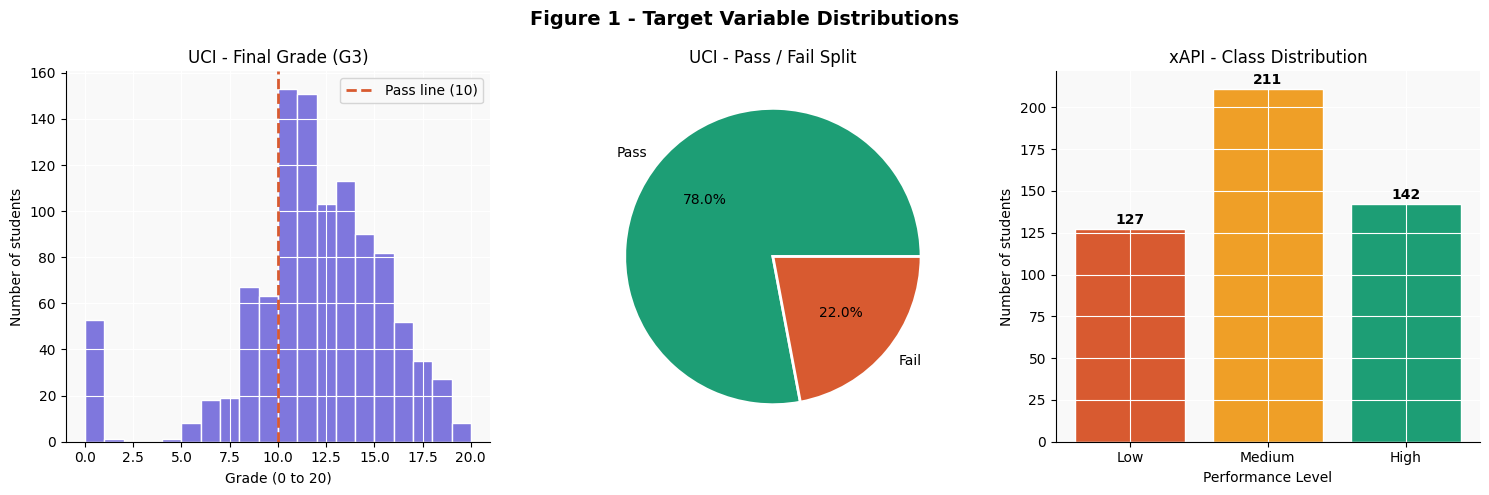

Saved -> fig1_target_variables.png


In [ ]:
# Figure 1: Target variable distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 1 - Target Variable Distributions', fontsize=14, fontweight='bold')

# Plot 1: UCI G3 histogram
axes[0].hist(uci['G3'], bins=20, color=PURPLE, edgecolor='white')
axes[0].axvline(10, color=CORAL, linewidth=2, linestyle='--', label='Pass line (10)')
axes[0].set_title('UCI - Final Grade (G3)')
axes[0].set_xlabel('Grade (0 to 20)')
axes[0].set_ylabel('Number of students')
axes[0].legend()

# Plot 2: UCI Pass/Fail pie
pf = uci['pass_fail'].value_counts()
axes[1].pie(pf, labels=pf.index, autopct='%1.1f%%',
            colors=[TEAL, CORAL],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('UCI - Pass / Fail Split')

# Plot 3: xAPI class bar chart
cl = xapi['Class'].value_counts().reindex(['L','M','H'])
bars = axes[2].bar(['Low','Medium','High'], cl.values,
                   color=[CORAL, AMBER, TEAL], edgecolor='white')
for bar, val in zip(bars, cl.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3, str(val), ha='center', fontweight='bold')
axes[2].set_title('xAPI - Class Distribution')
axes[2].set_xlabel('Performance Level')
axes[2].set_ylabel('Number of students')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig1_target_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> fig1_target_variables.png')

---
## Section 4 - UCI Dataset: Key Feature Distributions

Most important features to look at:
- **studytime** - hours per week (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)
- **failures** - number of past class failures
- **absences** - number of school absences
- **Medu/Fedu** - mother/father education (0-4)
- **G1, G2** - intermediate grades (best predictors of G3)

In [ ]:
key_cols = ['studytime','failures','absences','Medu','Fedu','G1','G2','G3']
print('Summary statistics for key UCI features:')
uci[key_cols].describe().round(2)

Summary statistics for key UCI features:


,studytime,failures,absences,Medu,Fedu,G1,G2,G3
count,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00
mean,1.97,0.26,4.43,2.60,2.39,11.21,11.25,11.34
std,0.83,0.66,6.21,1.12,1.10,2.98,3.29,3.86
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,2.00,1.00,9.00,9.00,10.00
50%,2.00,0.00,2.00,3.00,2.00,11.00,11.00,11.00
75%,2.00,0.00,6.00,4.00,3.00,13.00,13.00,14.00
max,4.00,3.00,75.00,4.00,4.00,19.00,19.00,20.00


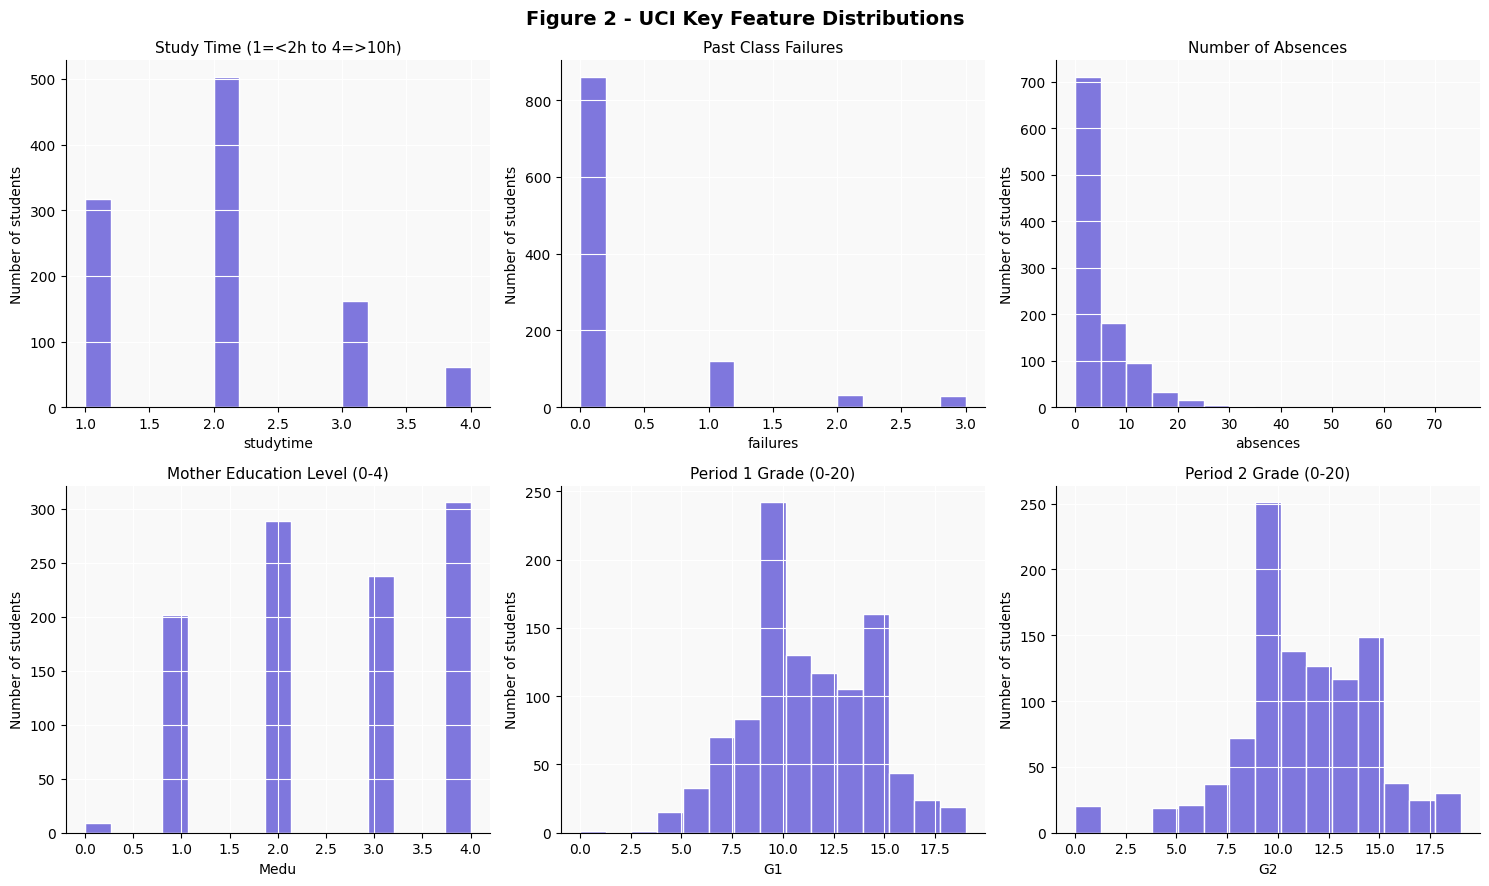

In [ ]:
# Figure 2: Key feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Figure 2 - UCI Key Feature Distributions', fontsize=14, fontweight='bold')

features = [
    ('studytime', 'Study Time (1=<2h to 4=>10h)'),
    ('failures',  'Past Class Failures'),
    ('absences',  'Number of Absences'),
    ('Medu',      'Mother Education Level (0-4)'),
    ('G1',        'Period 1 Grade (0-20)'),
    ('G2',        'Period 2 Grade (0-20)'),
]

for ax, (col, label) in zip(axes.flat, features):
    ax.hist(uci[col], bins=15, color=PURPLE, edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Number of students')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig2_uci_features.png', dpi=150, bbox_inches='tight')
plt.show()

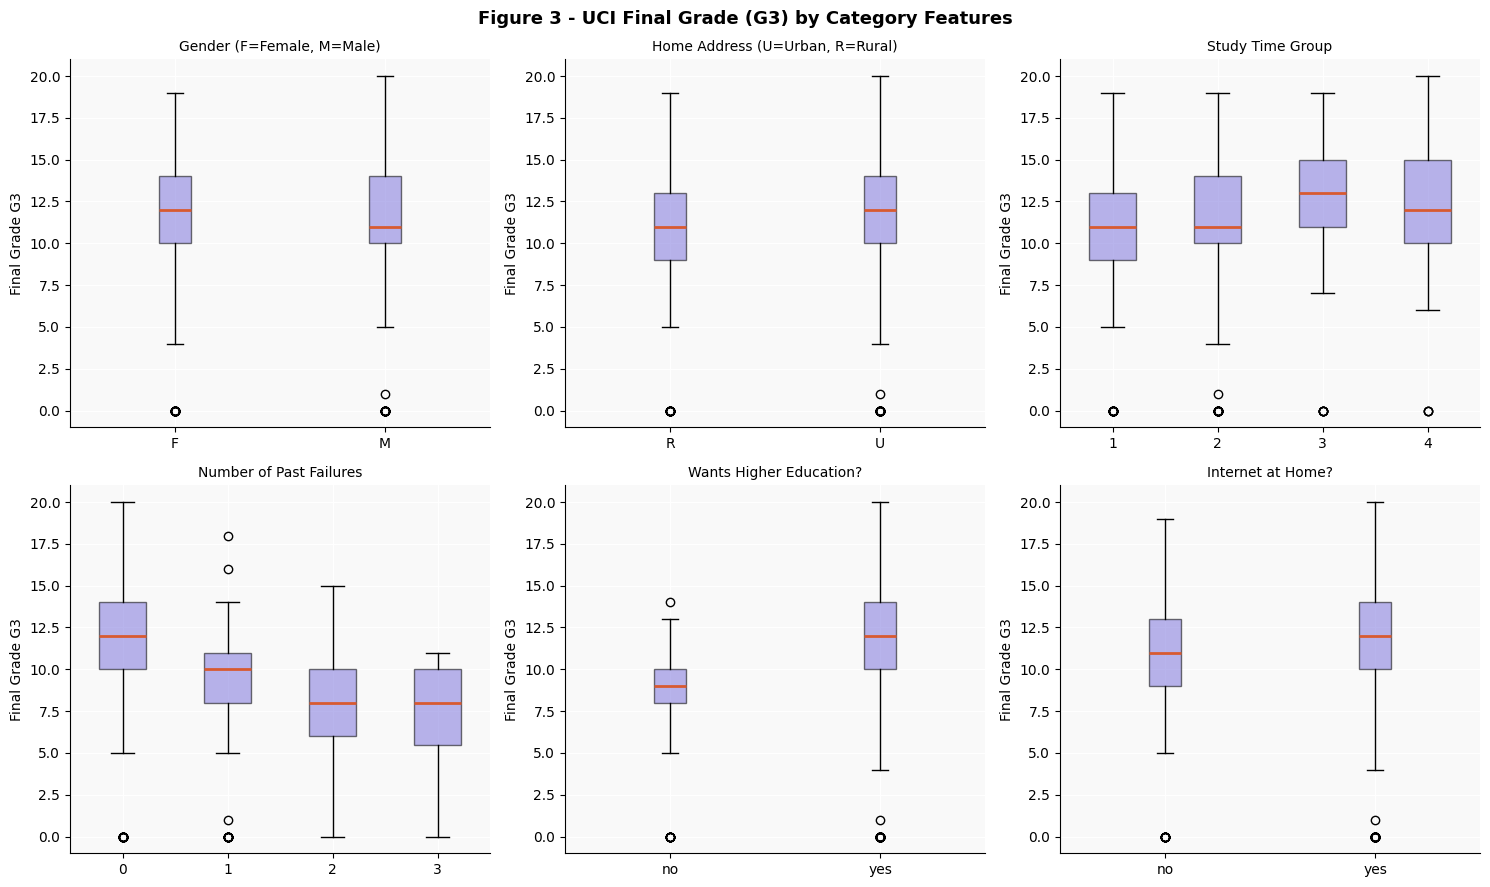

In [ ]:
# Figure 3: How category features affect G3
# A boxplot shows the spread of grades for each group.
# The line in the middle = median grade.

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Figure 3 - UCI Final Grade (G3) by Category Features',
             fontsize=13, fontweight='bold')

cat_features = [
    ('sex',      'Gender (F=Female, M=Male)'),
    ('address',  'Home Address (U=Urban, R=Rural)'),
    ('studytime','Study Time Group'),
    ('failures', 'Number of Past Failures'),
    ('higher',   'Wants Higher Education?'),
    ('internet', 'Internet at Home?'),
]

for ax, (col, label) in zip(axes.flat, cat_features):
    groups = [uci.loc[uci[col] == v, 'G3'].values for v in sorted(uci[col].unique())]
    lbs    = sorted(uci[col].unique())
    bp = ax.boxplot(groups, labels=lbs, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(PURPLE); patch.set_alpha(0.55)
    for med in bp['medians']:
        med.set_color(CORAL); med.set_linewidth(2)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Final Grade G3')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig3_uci_grade_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

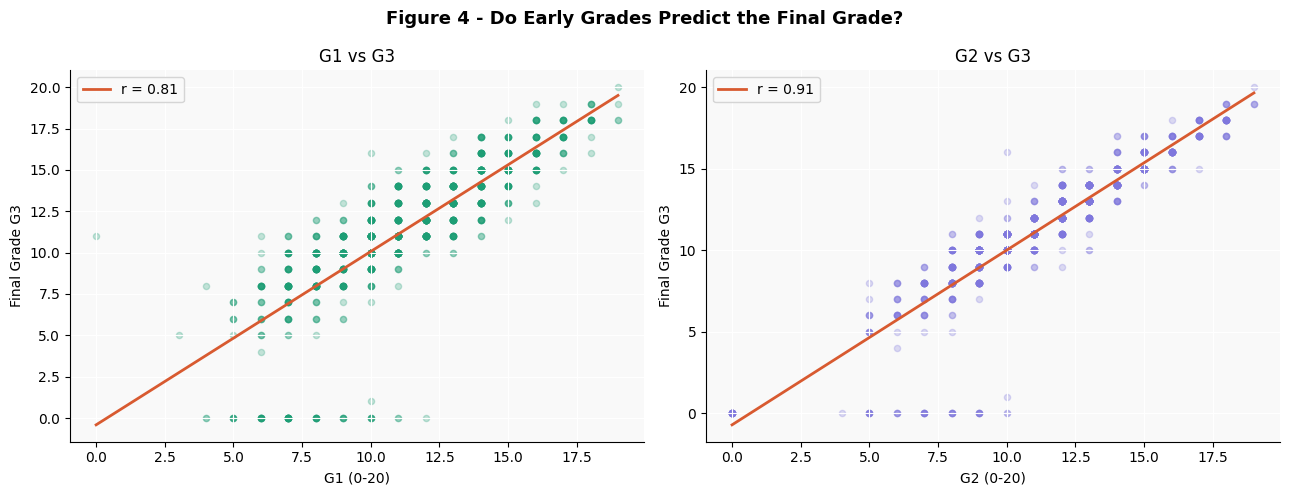


G1 to G3 correlation: 0.809
G2 to G3 correlation: 0.911
Interpretation: r close to 1.0 means very strong positive link.


In [ ]:
# Figure 4: Do G1 and G2 predict G3?
# r = correlation coefficient.  Closer to 1.0 = stronger link.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4 - Do Early Grades Predict the Final Grade?',
             fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['G1','G2'], [TEAL, PURPLE]):
    ax.scatter(uci[col], uci['G3'], alpha=0.25, color=color, s=20)
    m, b = np.polyfit(uci[col], uci['G3'], 1)
    x = np.linspace(uci[col].min(), uci[col].max(), 100)
    r = uci[col].corr(uci['G3'])
    ax.plot(x, m*x + b, color=CORAL, linewidth=2, label='r = ' + str(round(r, 2)))
    ax.set_xlabel(col + ' (0-20)')
    ax.set_ylabel('Final Grade G3')
    ax.set_title(col + ' vs G3')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig4_uci_grade_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('G1 to G3 correlation:', round(uci["G1"].corr(uci["G3"]), 3))
print('G2 to G3 correlation:', round(uci["G2"].corr(uci["G3"]), 3))
print('Interpretation: r close to 1.0 means very strong positive link.')

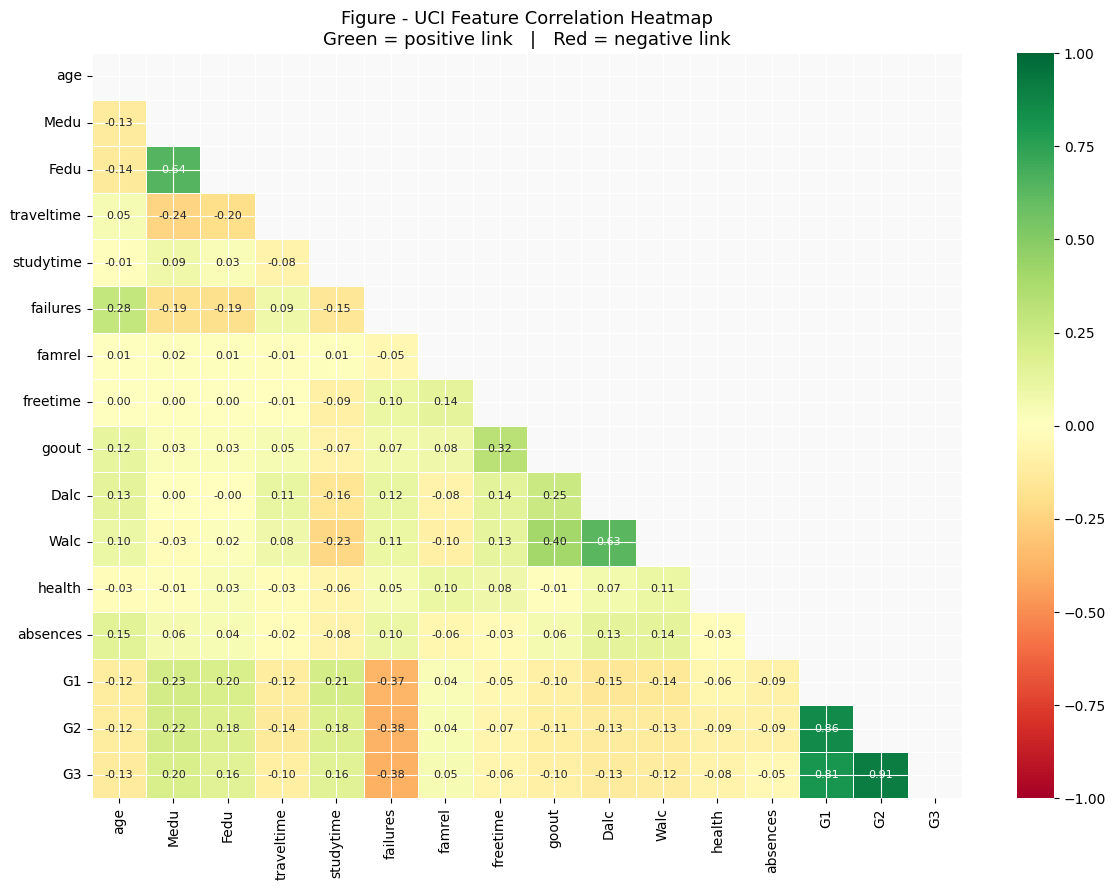


Top correlations with G3:
  G2           0.911 (positive)
  G1           0.809 (positive)
  Medu         0.201 (positive)
  studytime    0.162 (positive)
  Fedu         0.16 (positive)
  famrel       0.054 (positive)
  absences     -0.046 (negative)
  freetime     -0.065 (negative)
  health       -0.08 (negative)
  goout        -0.098 (negative)
  traveltime   -0.103 (negative)
  Walc         -0.116 (negative)
  age          -0.125 (negative)
  Dalc         -0.13 (negative)
  failures     -0.383 (negative)


In [ ]:
# Figure 5: Correlation heatmap
# Green = features move together. Red = one goes up, the other goes down.

fig, ax = plt.subplots(figsize=(12, 9))

num_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
            'famrel','freetime','goout','Dalc','Walc','health','absences',
            'G1','G2','G3']
corr = uci[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', annot_kws={'size': 8},
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', mask=mask, ax=ax)
ax.set_title('Figure - UCI Feature Correlation Heatmap\n'
             'Green = positive link   |   Red = negative link',
             fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig5_uci_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Top correlations with G3:')
top = corr['G3'].drop('G3').sort_values(ascending=False)
for feat, val in top.items():
    direction = 'positive' if val > 0 else 'negative'
    print(' ', feat.ljust(12), round(val, 3), '(' + direction + ')')

---
## Section 5 - xAPI Dataset: Engagement Behaviour

The 4 engagement columns are the heart of xAPI:
- `raisedhands` - times raised hand (0-100)
- `VisITedResources` - learning resources visited (0-99)
- `AnnouncementsView` - announcements read (0-98)
- `Discussion` - discussion posts (0-99)

In [ ]:
engagement_cols = ['raisedhands','VisITedResources','AnnouncementsView','Discussion']
print('xAPI Engagement Feature Statistics:')
xapi[engagement_cols].describe().round(1)

xAPI Engagement Feature Statistics:


,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.0,480.0,480.0,480.0
mean,46.8,54.8,37.9,43.3
std,30.8,33.1,26.6,27.6
min,0.0,0.0,0.0,1.0
25%,15.8,20.0,14.0,20.0
50%,50.0,65.0,33.0,39.0
75%,75.0,84.0,58.0,70.0
max,100.0,99.0,98.0,99.0


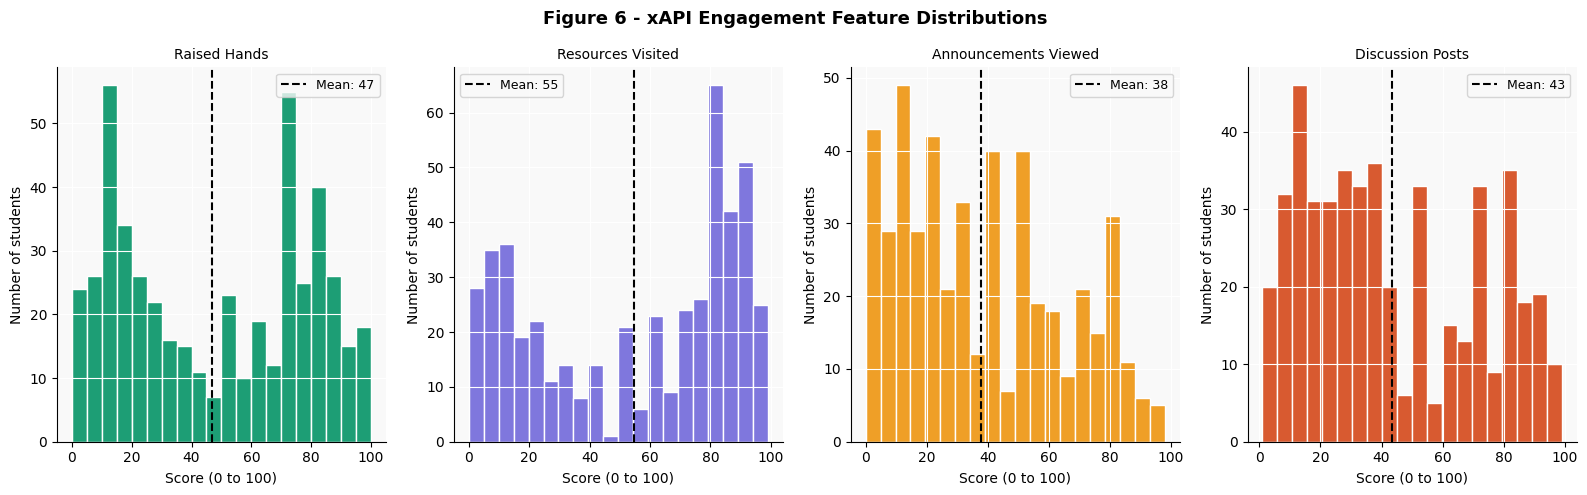

In [ ]:
# Figure 6: Distribution of each engagement feature
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Figure 6 - xAPI Engagement Feature Distributions',
             fontsize=13, fontweight='bold')

colors = [TEAL, PURPLE, AMBER, CORAL]
labels = ['Raised Hands','Resources Visited','Announcements Viewed','Discussion Posts']

for ax, col, label, color in zip(axes, engagement_cols, labels, colors):
    ax.hist(xapi[col], bins=20, color=color, edgecolor='white')
    mean_val = xapi[col].mean()
    ax.axvline(mean_val, color='black', linewidth=1.5,
               linestyle='--', label='Mean: ' + str(round(mean_val)))
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score (0 to 100)')
    ax.set_ylabel('Number of students')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig6_xapi_engagement_dist.png', dpi=150, bbox_inches='tight')
plt.show()

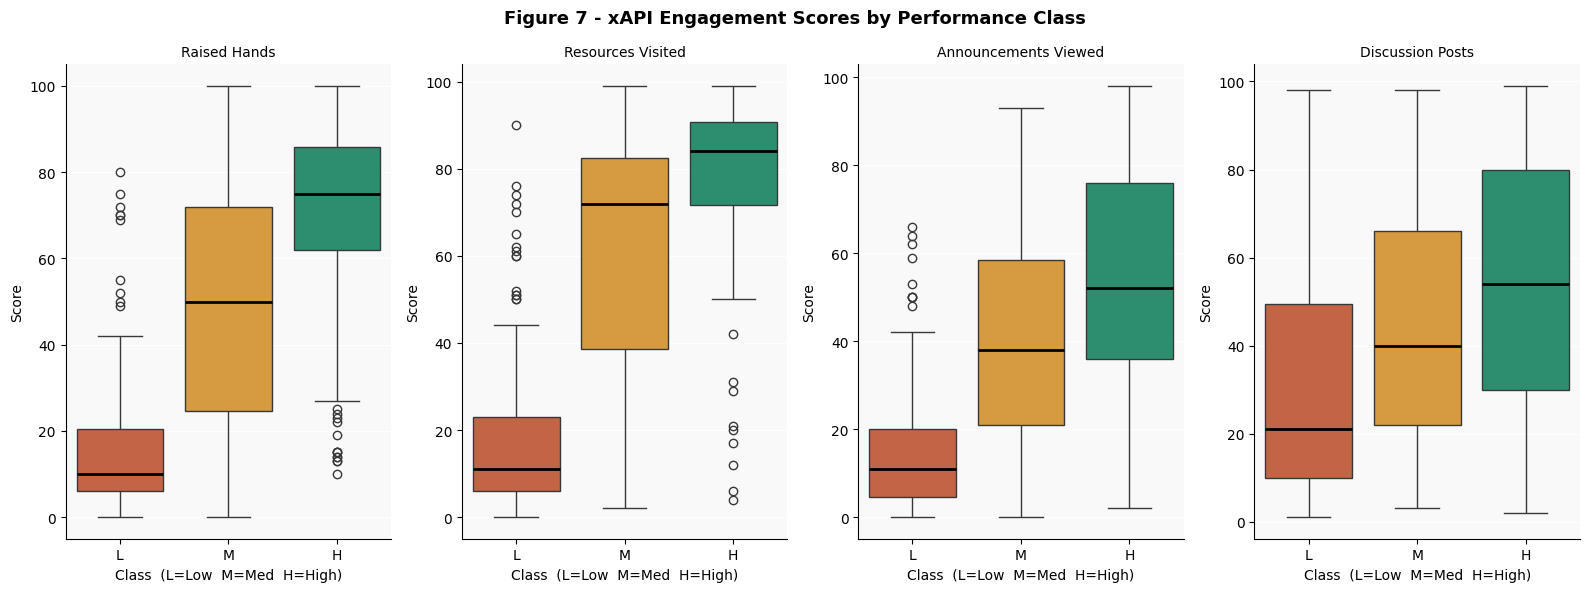


Mean engagement per class:
       raisedhands  VisITedResources  AnnouncementsView  Discussion
Class                                                              
L             16.9              18.3               15.6        30.8
M             48.9              60.6               41.0        43.8
H             70.3              78.7               53.4        53.7


In [ ]:
# Figure 7: Do engaged students perform better?
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle('Figure 7 - xAPI Engagement Scores by Performance Class',
             fontsize=13, fontweight='bold')

palette = {'L': CORAL, 'M': AMBER, 'H': TEAL}

for ax, col, label in zip(axes, engagement_cols, labels):
    sns.boxplot(data=xapi, x='Class', y=col, order=['L','M','H'],
                palette=palette, ax=ax,
                medianprops=dict(color='black', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Class  (L=Low  M=Med  H=High)')
    ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig7_xapi_engagement_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Mean engagement per class:')
print(xapi.groupby('Class')[engagement_cols].mean().round(1).reindex(['L','M','H']).to_string())

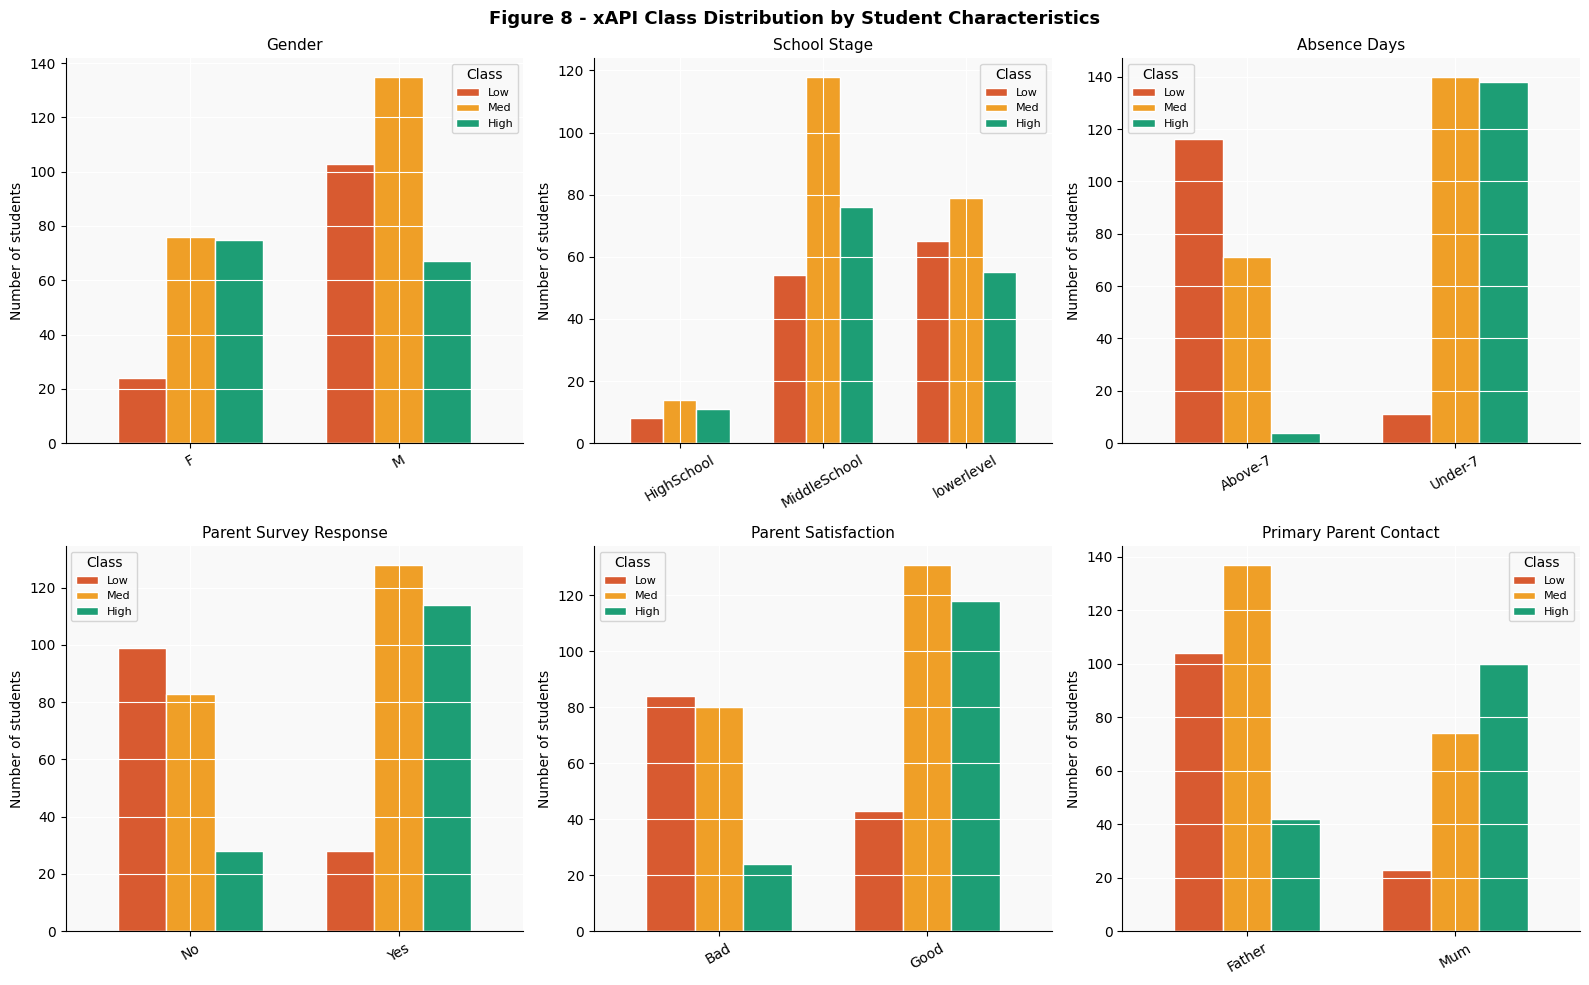

In [ ]:
# Figure 8: Other xAPI features vs class
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 8 - xAPI Class Distribution by Student Characteristics',
             fontsize=13, fontweight='bold')

cat_cols = [
    ('gender',                   'Gender'),
    ('StageID',                  'School Stage'),
    ('StudentAbsenceDays',       'Absence Days'),
    ('ParentAnsweringSurvey',    'Parent Survey Response'),
    ('ParentschoolSatisfaction', 'Parent Satisfaction'),
    ('Relation',                 'Primary Parent Contact'),
]

for ax, (col, label) in zip(axes.flat, cat_cols):
    ct = pd.crosstab(xapi[col], xapi['Class'])[['L','M','H']]
    ct.plot(kind='bar', ax=ax, color=[CORAL, AMBER, TEAL], edgecolor='white', width=0.7)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Number of students')
    ax.legend(title='Class', labels=['Low','Med','High'], fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig8_xapi_categories.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 - Comparing Both Datasets: Shared Themes

UCI and xAPI are different schools so we cannot merge them row-by-row.
But we can compare the same **themes** across both to find patterns that appear in both.

| Theme | UCI column | xAPI column |
|-------|-----------|-------------|
| Gender | `sex` | `gender` |
| Absences | `absences` (count) | `StudentAbsenceDays` (Under/Above 7) |
| Parent involvement | `famsup` (yes/no) | `ParentAnsweringSurvey` (Yes/No) |
| Study engagement | `studytime` (1-4) | `raisedhands` + `VisITedResources` |

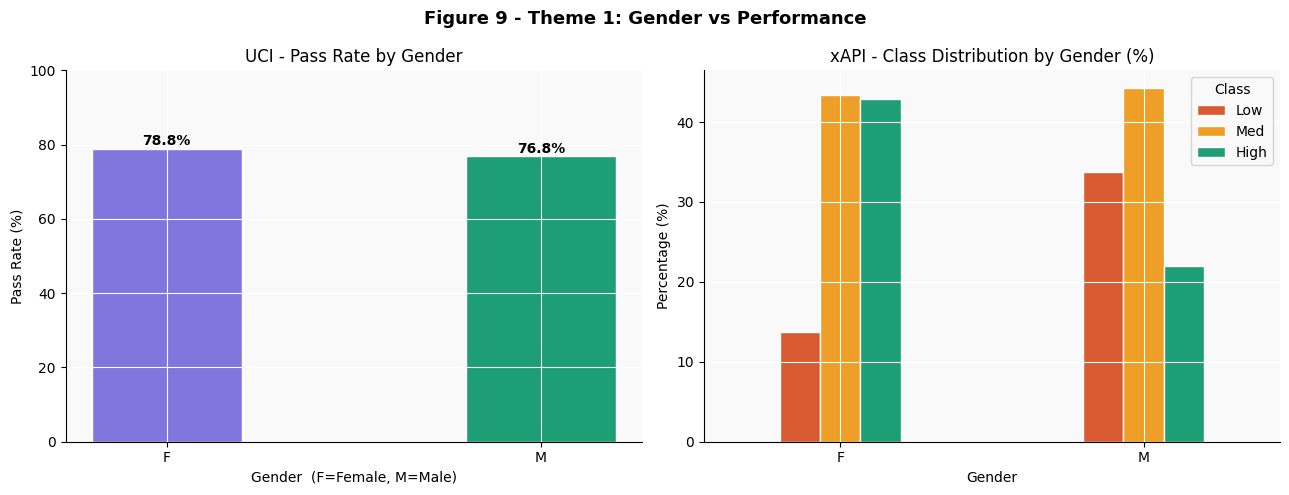

In [ ]:
# Figure 9: Gender vs Performance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 9 - Theme 1: Gender vs Performance', fontsize=13, fontweight='bold')

# UCI pass rate by gender
uci_g = (uci.groupby('sex')['pass_fail']
            .apply(lambda x: (x=='Pass').mean()*100).reset_index())
uci_g.columns = ['sex','pass_rate']
bars = axes[0].bar(uci_g['sex'], uci_g['pass_rate'],
                   color=[PURPLE, TEAL], edgecolor='white', width=0.4)
for bar, val in zip(bars, uci_g['pass_rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1, str(round(val,1))+'%',
                 ha='center', fontweight='bold')
axes[0].set_title('UCI - Pass Rate by Gender')
axes[0].set_xlabel('Gender  (F=Female, M=Male)')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].set_ylim(0, 100)

# xAPI class % by gender
ct = pd.crosstab(xapi['gender'], xapi['Class'])[['L','M','H']]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[1], color=[CORAL, AMBER, TEAL],
            edgecolor='white', width=0.4)
axes[1].set_title('xAPI - Class Distribution by Gender (%)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Class', labels=['Low','Med','High'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig9_gender_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

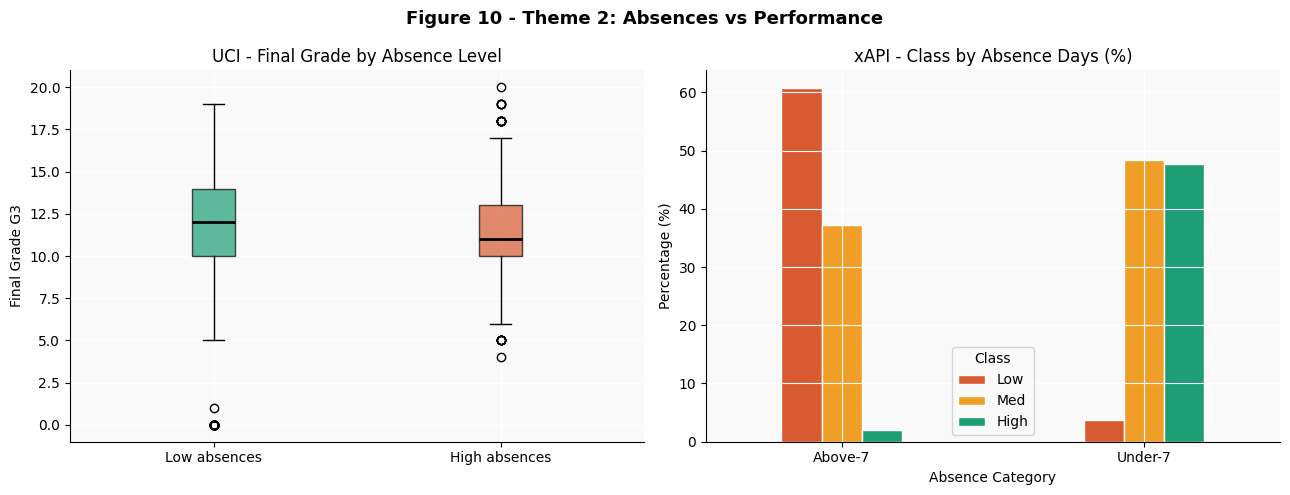

In [ ]:
# Figure 10: Absences vs Performance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 10 - Theme 2: Absences vs Performance', fontsize=13, fontweight='bold')

# UCI: boxplot G3 by absence group (split at median)
med_abs = int(uci['absences'].median())
uci['absence_group'] = uci['absences'].apply(
    lambda x: 'High (>' + str(med_abs) + ')' if x > med_abs
              else 'Low (<=' + str(med_abs) + ')')
low_label  = 'Low (<=' + str(med_abs) + ')'
high_label = 'High (>' + str(med_abs) + ')'
groups = [uci.loc[uci['absence_group']==low_label,  'G3'].values,
          uci.loc[uci['absence_group']==high_label, 'G3'].values]
bp = axes[0].boxplot(groups, labels=['Low absences','High absences'], patch_artist=True)
for patch, col in zip(bp['boxes'], [TEAL, CORAL]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(2)
axes[0].set_title('UCI - Final Grade by Absence Level')
axes[0].set_ylabel('Final Grade G3')

# xAPI: class % by absence category
ct = pd.crosstab(xapi['StudentAbsenceDays'], xapi['Class'])[['L','M','H']]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[1], color=[CORAL, AMBER, TEAL],
            edgecolor='white', width=0.4)
axes[1].set_title('xAPI - Class by Absence Days (%)')
axes[1].set_xlabel('Absence Category')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Class', labels=['Low','Med','High'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig10_absence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

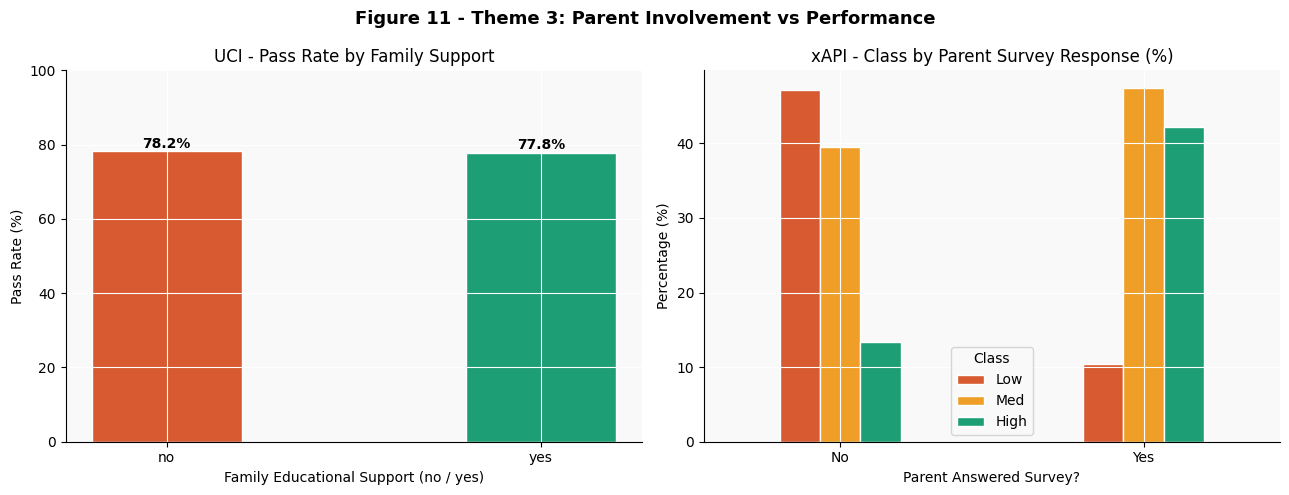

In [ ]:
# Figure 11: Parent Involvement vs Performance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 11 - Theme 3: Parent Involvement vs Performance',
             fontsize=13, fontweight='bold')

# UCI: pass rate by family support
uci_fam = (uci.groupby('famsup')['pass_fail']
              .apply(lambda x: (x=='Pass').mean()*100).reset_index())
uci_fam.columns = ['famsup','pass_rate']
bars = axes[0].bar(uci_fam['famsup'], uci_fam['pass_rate'],
                   color=[CORAL, TEAL], edgecolor='white', width=0.4)
for bar, val in zip(bars, uci_fam['pass_rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1, str(round(val,1))+'%',
                 ha='center', fontweight='bold')
axes[0].set_title('UCI - Pass Rate by Family Support')
axes[0].set_xlabel('Family Educational Support (no / yes)')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].set_ylim(0, 100)

# xAPI: class % by parent survey
ct = pd.crosstab(xapi['ParentAnsweringSurvey'], xapi['Class'])[['L','M','H']]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[1], color=[CORAL, AMBER, TEAL],
            edgecolor='white', width=0.4)
axes[1].set_title('xAPI - Class by Parent Survey Response (%)')
axes[1].set_xlabel('Parent Answered Survey?')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Class', labels=['Low','Med','High'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig11_parent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

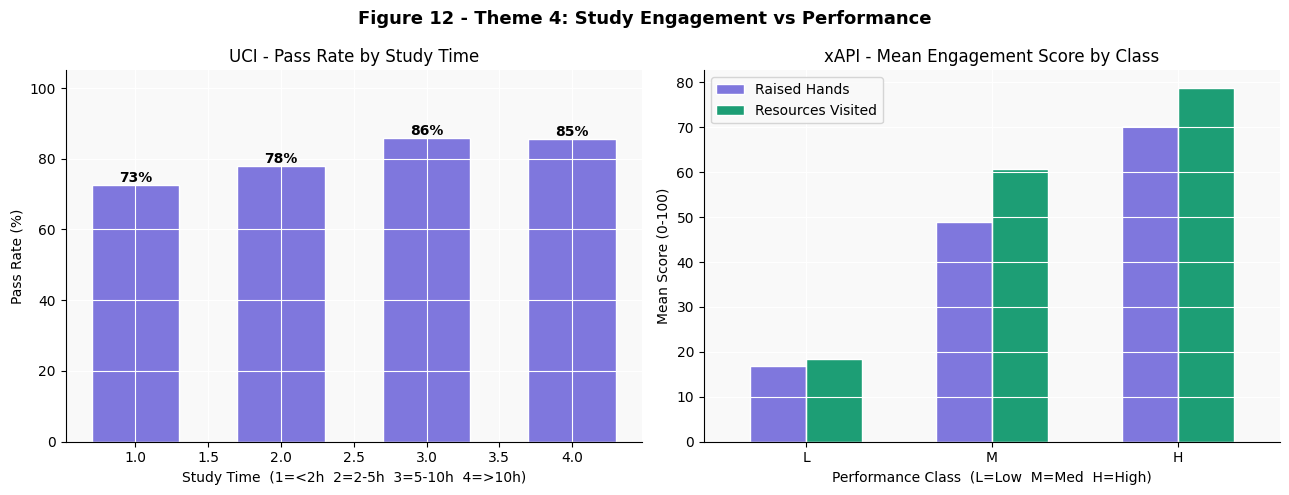

In [ ]:
# Figure 12: Study Engagement vs Performance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 12 - Theme 4: Study Engagement vs Performance',
             fontsize=13, fontweight='bold')

# UCI: pass rate by study time
uci_st = (uci.groupby('studytime')['pass_fail']
             .apply(lambda x: (x=='Pass').mean()*100).reset_index())
uci_st.columns = ['studytime','pass_rate']
bars = axes[0].bar(uci_st['studytime'], uci_st['pass_rate'],
                   color=PURPLE, edgecolor='white', width=0.6)
for bar, val in zip(bars, uci_st['pass_rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1, str(round(val))+'%',
                 ha='center', fontweight='bold')
axes[0].set_title('UCI - Pass Rate by Study Time')
axes[0].set_xlabel('Study Time  (1=<2h  2=2-5h  3=5-10h  4=>10h)')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].set_ylim(0, 105)

# xAPI: mean engagement by class
eng_means = xapi.groupby('Class')[['raisedhands','VisITedResources']].mean().reindex(['L','M','H'])
eng_means.plot(kind='bar', ax=axes[1], color=[PURPLE, TEAL],
               edgecolor='white', width=0.6)
axes[1].set_title('xAPI - Mean Engagement Score by Class')
axes[1].set_xlabel('Performance Class  (L=Low  M=Med  H=High)')
axes[1].set_ylabel('Mean Score (0-100)')
axes[1].legend(['Raised Hands','Resources Visited'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig12_engagement_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7 - Key EDA Findings Summary

Run this cell last. Copy the printed output into your report's **Data Description** section.

In [ ]:
pass_rate  = round((uci['G3'] >= 10).mean() * 100, 1)
mean_g3    = round(uci['G3'].mean(), 2)
g1_corr    = round(uci['G1'].corr(uci['G3']), 3)
g2_corr    = round(uci['G2'].corr(uci['G3']), 3)
fail_corr  = round(uci['failures'].corr(uci['G3']), 3)
abs_corr   = round(uci['absences'].corr(uci['G3']), 3)

xapi_l  = round((xapi['Class']=='L').mean()*100, 1)
xapi_m  = round((xapi['Class']=='M').mean()*100, 1)
xapi_h  = round((xapi['Class']=='H').mean()*100, 1)
high_abs= round((xapi['StudentAbsenceDays']=='Above-7').mean()*100, 1)
h_hands = round(xapi.loc[xapi['Class']=='H','raisedhands'].mean(), 1)
l_hands = round(xapi.loc[xapi['Class']=='L','raisedhands'].mean(), 1)
h_res   = round(xapi.loc[xapi['Class']=='H','VisITedResources'].mean(), 1)
l_res   = round(xapi.loc[xapi['Class']=='L','VisITedResources'].mean(), 1)

sep = '=' * 58
print(sep)
print('KEY EDA FINDINGS')
print(sep)
print()
print('UCI Dataset (' + str(len(uci)) + ' students: Math + Portuguese combined)')
print('  Overall pass rate          :', pass_rate, '%')
print('  Mean final grade (G3)      :', mean_g3, '/ 20')
print('  G1 predicts G3             : r =', g1_corr, '(strong positive)')
print('  G2 predicts G3             : r =', g2_corr, '(very strong - best predictor)')
print('  Past failures hurt G3      : r =', fail_corr, '(more failures = lower grade)')
print('  Absences hurt G3           : r =', abs_corr, '(more absences = lower grade)')
print()
print('xAPI Dataset (' + str(len(xapi)) + ' students)')
print('  Class Low  (L)             :', xapi_l, '% of students')
print('  Class Med  (M)             :', xapi_m, '% of students')
print('  Class High (H)             :', xapi_h, '% of students')
print('  Students with >7 absences  :', high_abs, '%')
print('  High class avg raised hands:', h_hands, ' vs Low class:', l_hands)
print('  High class avg resources   :', h_res,   ' vs Low class:', l_res)
print()
print('Cross-dataset Observations (both datasets agree on these)')
print('  1. More absences       -> worse performance')
print('  2. Parent involvement  -> better performance')
print('  3. More study/engagement -> better performance')
print('  4. UCI: students wanting higher education pass at a higher rate')
print('  5. xAPI: engaged students (raise hands, visit resources) score High')
print()
print('Conclusion:')
print('  Background factors (UCI) AND engagement behaviour (xAPI) both matter.')
print('  However, xAPI engagement features show a clearer and more direct')
print('  signal - highlight this in your paper.')
print()

KEY EDA FINDINGS

UCI Dataset (1044 students: Math + Portuguese combined)
  Overall pass rate          : 78.0 %
  Mean final grade (G3)      : 11.34 / 20
  G1 predicts G3             : r = 0.809 (strong positive)
  G2 predicts G3             : r = 0.911 (very strong - best predictor)
  Past failures hurt G3      : r = -0.383 (more failures = lower grade)
  Absences hurt G3           : r = -0.046 (more absences = lower grade)

xAPI Dataset (480 students)
  Class Low  (L)             : 26.5 % of students
  Class Med  (M)             : 44.0 % of students
  Class High (H)             : 29.6 % of students
  Students with >7 absences  : 39.8 %
  High class avg raised hands: 70.3  vs Low class: 16.9
  High class avg resources   : 78.7  vs Low class: 18.3

Cross-dataset Observations (both datasets agree on these)
  1. More absences       -> worse performance
  2. Parent involvement  -> better performance
  3. More study/engagement -> better performance
  4. UCI: students wanting higher educati